### **Problem :** Build a Linear Regression system that predicts salary based on experience, education, skills, and location.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files  #Comment out if you ar runnin locally

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [ ]:
uploaded = files.upload()  #Comment out if you ar runnin locally

Saving salary_prediction_data.csv to salary_prediction_data.csv


In [6]:
df = pd.read_csv('salary_prediction_data.csv')
df.head()

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Education   1000 non-null   object 
 1   Experience  1000 non-null   int64  
 2   Location    1000 non-null   object 
 3   Job_Title   1000 non-null   object 
 4   Age         1000 non-null   int64  
 5   Gender      1000 non-null   object 
 6   Salary      1000 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB


,0
Education,0
Experience,0
Location,0
Job_Title,0
Age,0
Gender,0
Salary,0


Handle Missing Values

In [8]:
# numerical
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].mean())

# categorical
for col in df.select_dtypes(exclude=np.number):
    df[col] = df[col].fillna(df[col].mode()[0])

Feature Engineering

In [9]:
# Experience squared (captures non-linear growth)
df['Experience_squared'] = df['Experience'] ** 2

Handle Categorical Variables

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
X = df.drop('Salary', axis=1)
y = df['Salary']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Multicollinearity (VIF)

In [15]:
X_numeric = X.astype(float) # Convert all columns to float, which will convert booleans to 0.0 and 1.0
X_vif = sm.add_constant(X_numeric)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

                  Feature        VIF
0                   const  28.085805
1              Experience  16.908868
2                     Age   1.013762
3      Experience_squared  16.975765
4   Education_High School   1.504292
5        Education_Master   1.501313
6           Education_PhD   1.506991
7       Location_Suburban   1.341919
8          Location_Urban   1.332884
9      Job_Title_Director   1.520729
10     Job_Title_Engineer   1.497029
11      Job_Title_Manager   1.493284
12            Gender_Male   1.012088


In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 8143.072378079123
MSE: 105812907.04126793
RMSE: 10286.54009087934
R2: 0.8704109421426346


Visualizations

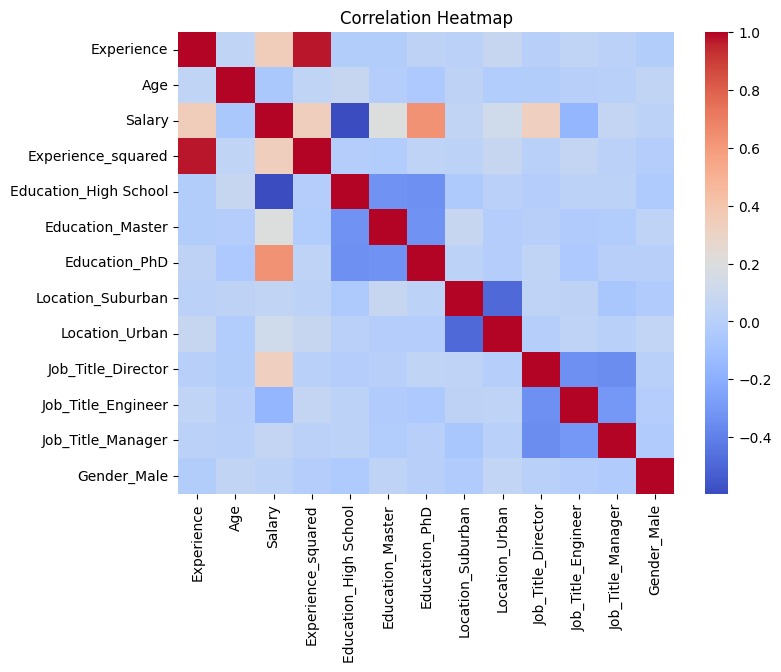

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

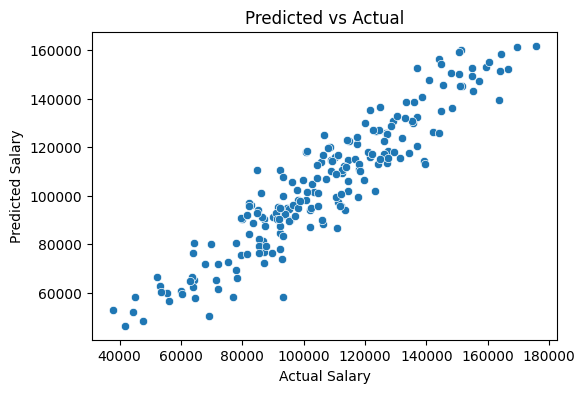

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Predicted vs Actual")
plt.show()

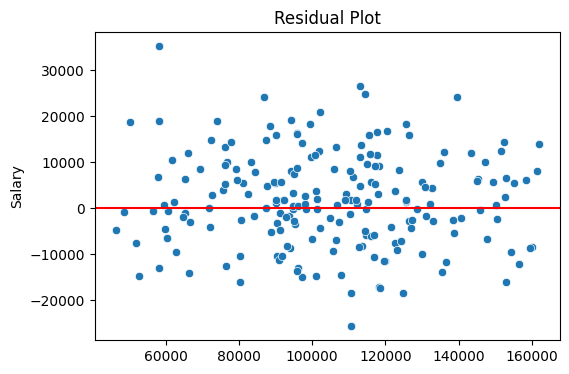

In [20]:
residuals = y_test - pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

In [21]:
comparison_df = pd.DataFrame({
    'Actual Salary': y_test.values[:10],
    'Predicted Salary': pred[:10]
})

comparison_df

,Actual Salary,Predicted Salary
0,86677.840109,81170.811201
1,56036.163010,56615.114912
2,92226.871819,110698.510218
3,100710.088052,98044.470224
4,91775.012832,93581.730910
5,52282.492625,66404.841818
6,102139.813085,94104.006683
7,127491.152115,118262.582690
8,117342.186715,121418.164750
9,99647.042817,106634.892858
